In [ ]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import gc
import holidays
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight


#from fcmeans import FCM

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install fuzzy-c-means

#Data preparation:

##Data loading

1.train data

In [ ]:
months = [f"{i:02d}" for i in range(1, 13)]

for m in months:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-{m}.parquet"
    if not os.path.exists(f"yellow_tripdata_2023-{m}.parquet"):
        os.system(f"wget {url}")

2.test data

In [ ]:
test_months = ['02','05','08','11']

for m in test_months:
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{m}.parquet"
    if not os.path.exists(f"yellow_tripdata_2024-{m}.parquet"):
        os.system(f"wget {url}")

In [ ]:
df = pd.read_parquet("/content/yellow_tripdata_2024-11.parquet")

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,262,2,-12.8,-1.0,-0.5,0.0,0.0,-1.0,-17.8,-2.5,0.0
1,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,263,2,12.8,1.0,0.5,0.0,0.0,1.0,17.8,2.5,0.0
2,1,2024-11-01 00:37:36,2024-11-01 01:28:36,1.0,34.30,5.0,N,219,265,1,259.0,0.0,0.0,15.0,0.0,1.0,275.0,0.0,0.0
3,2,2024-11-01 00:12:55,2024-11-01 00:22:17,2.0,0.93,1.0,N,186,107,1,10.0,1.0,0.5,1.0,0.0,1.0,16.0,2.5,0.0
4,2,2024-11-01 00:54:45,2024-11-01 00:59:47,1.0,0.38,1.0,N,79,79,1,6.5,1.0,0.5,1.0,0.0,1.0,12.5,2.5,0.0


In [ ]:
import os

# حذف الملفات الفاسدة
months = [f"{i:02d}" for i in range(1, 13)]
test_months = ['02', '05', '08', '11']

for m in months:
    f = f"yellow_tripdata_2023-{m}.parquet"
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑 Deleted {f}")

for m in test_months:
    f = f"yellow_tripdata_2024-{m}.parquet"
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑 Deleted {f}")

print("✅ Done cleaning.")

🗑 Deleted yellow_tripdata_2023-01.parquet
🗑 Deleted yellow_tripdata_2023-02.parquet
🗑 Deleted yellow_tripdata_2023-03.parquet
🗑 Deleted yellow_tripdata_2023-04.parquet
🗑 Deleted yellow_tripdata_2023-05.parquet
🗑 Deleted yellow_tripdata_2023-06.parquet
🗑 Deleted yellow_tripdata_2023-07.parquet
🗑 Deleted yellow_tripdata_2023-08.parquet
🗑 Deleted yellow_tripdata_2023-09.parquet
🗑 Deleted yellow_tripdata_2023-10.parquet
🗑 Deleted yellow_tripdata_2023-11.parquet
🗑 Deleted yellow_tripdata_2023-12.parquet
🗑 Deleted yellow_tripdata_2024-02.parquet
🗑 Deleted yellow_tripdata_2024-05.parquet
🗑 Deleted yellow_tripdata_2024-08.parquet
🗑 Deleted yellow_tripdata_2024-11.parquet
✅ Done cleaning.


In [ ]:
import os
import requests

def download_parquet(url, filename):
    """Download with validation — retries up to 3 times"""
    for attempt in range(1, 4):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            with open(filename, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                    f.write(chunk)
            # Validate: parquet magic bytes are PAR1
            with open(filename, 'rb') as f:
                header = f.read(4)
                f.seek(-4, 2)
                footer = f.read(4)
            if header == b'PAR1' and footer == b'PAR1':
                size_mb = os.path.getsize(filename) / 1024 / 1024
                print(f"  ✅ {filename}  ({size_mb:.1f} MB)")
                return True
            else:
                print(f"  ⚠ Attempt {attempt}: invalid parquet, retrying...")
                os.remove(filename)
        except Exception as e:
            print(f"  ⚠ Attempt {attempt} failed: {e}")
            if os.path.exists(filename):
                os.remove(filename)
    print(f"  ❌ FAILED after 3 attempts: {filename}")
    return False

# Train data (2023)
months = [f"{i:02d}" for i in range(1, 13)]
print("=== Downloading 2023 train data ===")
for m in months:
    fname = f"yellow_tripdata_2023-{m}.parquet"
    if os.path.exists(fname):
        print(f"  ⏭ Already exists: {fname}")
        continue
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-{m}.parquet"
    download_parquet(url, fname)

# Test data (2024)
test_months = ['02', '05', '08', '11']
print("\n=== Downloading 2024 test data ===")
for m in test_months:
    fname = f"yellow_tripdata_2024-{m}.parquet"
    if os.path.exists(fname):
        print(f"  ⏭ Already exists: {fname}")
        continue
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{m}.parquet"
    download_parquet(url, fname)

print("\n✅ All downloads complete.")

=== Downloading 2023 train data ===
  ✅ yellow_tripdata_2023-01.parquet  (45.5 MB)
  ✅ yellow_tripdata_2023-02.parquet  (45.5 MB)
  ✅ yellow_tripdata_2023-03.parquet  (53.5 MB)
  ✅ yellow_tripdata_2023-04.parquet  (51.7 MB)
  ✅ yellow_tripdata_2023-05.parquet  (55.9 MB)
  ✅ yellow_tripdata_2023-06.parquet  (52.5 MB)
  ✅ yellow_tripdata_2023-07.parquet  (46.1 MB)
  ✅ yellow_tripdata_2023-08.parquet  (45.9 MB)
  ✅ yellow_tripdata_2023-09.parquet  (45.7 MB)
  ✅ yellow_tripdata_2023-10.parquet  (56.3 MB)
  ✅ yellow_tripdata_2023-11.parquet  (53.5 MB)
  ✅ yellow_tripdata_2023-12.parquet  (54.2 MB)

=== Downloading 2024 test data ===
  ✅ yellow_tripdata_2024-02.parquet  (48.0 MB)
  ✅ yellow_tripdata_2024-05.parquet  (59.7 MB)
  ✅ yellow_tripdata_2024-08.parquet  (48.7 MB)
  ✅ yellow_tripdata_2024-11.parquet  (57.8 MB)

✅ All downloads complete.


In [ ]:
import pandas as pd

all_ok = True
for m in months:
    fname = f"yellow_tripdata_2023-{m}.parquet"
    try:
        df_check = pd.read_parquet(fname, columns=['tpep_pickup_datetime'])
        print(f"  ✅ {fname}  ({len(df_check):,} rows)")
        del df_check
    except Exception as e:
        print(f"  ❌ {fname}: {e}")
        all_ok = False

if all_ok:
    print("\n✅ All files valid. Ready to run the notebook.")
else:
    print("\n❌ Some files still corrupted — re-run the download cell.")

  ✅ yellow_tripdata_2023-01.parquet  (3,066,766 rows)
  ✅ yellow_tripdata_2023-02.parquet  (2,913,955 rows)
  ✅ yellow_tripdata_2023-03.parquet  (3,403,766 rows)
  ✅ yellow_tripdata_2023-04.parquet  (3,288,250 rows)
  ✅ yellow_tripdata_2023-05.parquet  (3,513,649 rows)
  ✅ yellow_tripdata_2023-06.parquet  (3,307,234 rows)
  ✅ yellow_tripdata_2023-07.parquet  (2,907,108 rows)
  ✅ yellow_tripdata_2023-08.parquet  (2,824,209 rows)
  ✅ yellow_tripdata_2023-09.parquet  (2,846,722 rows)
  ✅ yellow_tripdata_2023-10.parquet  (3,522,285 rows)
  ✅ yellow_tripdata_2023-11.parquet  (3,339,715 rows)
  ✅ yellow_tripdata_2023-12.parquet  (3,376,567 rows)

✅ All files valid. Ready to run the notebook.


#Cleaning & Feature Engineering _Train data:

In [ ]:
import pandas as pd
import gc

batch_size = 100000
demand_results = []
supply_results = []
final_results = []
us_holidays = holidays.US()

for m in months:
    print(f"Processing Month: {m}")

    file_path = f"yellow_tripdata_2023-{m}.parquet"
    df = pd.read_parquet(file_path)

    # --- TIME ---
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

    # Drop rows where 'tpep_pickup_datetime' is NaT
    #df = df.dropna(subset=['tpep_pickup_datetime'])

    #  NEW FEATURE (month)
    df['month'] = df['tpep_pickup_datetime'].dt.month
    # Add day of month
    df['day'] = df['tpep_pickup_datetime'].dt.day

    # --- CLEANING ---
    df = df[
        (df['fare_amount'] > 0) &
        (df['trip_distance'] > 0) &
        (df['total_amount'] > 0) &
        (df['passenger_count'] > 0)
    ]

    # --- FEATURES ---
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour
    df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

    df['duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60

    df = df[(df['duration_minutes'] > 0) & (df['duration_minutes'] <= 240)]

    # 🔥 CHUNK PROCESSING
    for i in range(0, len(df), batch_size):
        chunk = df.iloc[i:i+batch_size].copy()

        # --- DEMAND ---
        demand = chunk.groupby(
            ['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour']
        ).size().reset_index(name='demand')

        # --- SUPPLY ---
        supply = chunk.groupby(
            ['DOLocationID', 'month', 'day', 'day_of_week', 'dropoff_hour']
        ).size().reset_index(name='supply')

        demand_results.append(demand)
        supply_results.append(supply)


        #  MERGE INSIDE LOOP
        final = pd.merge(
            demand,
            supply.rename(columns={
                'DOLocationID': 'PULocationID',
                'dropoff_hour': 'pickup_hour'
            }),
            on=['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour'],
            how='outer'
        ).fillna(0)

        final_results.append(final)

        # --- CLEAN ---
        del chunk
        gc.collect()

    del df
    gc.collect()

# FINAL CONCAT
final_df = pd.concat(final_results)

final_df = final_df.groupby(
    ['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour']
)[['demand', 'supply']].sum().reset_index()

final_df['is_weekend'] = final_df['day_of_week'].isin([5,6]).astype(int)

# Add is_holiday column
final_df['date'] = pd.to_datetime(
    dict(year=2023,
         month=final_df['month'],
         day=final_df['day'])
)

final_df['is_holiday'] = final_df['date'].isin(us_holidays).astype(int)

# --- IMBALANCE ---
final_df['imbalance'] = final_df['demand'] - final_df['supply']

final_df = final_df[
    ['PULocationID', 'month','day', 'day_of_week', 'pickup_hour',
     'is_weekend','is_holiday', 'demand', 'supply', 'imbalance']
]

print("✅ Done Processing Full Year with Month, Weekend and Holiday Features!")

Processing Month: 01
Processing Month: 02
Processing Month: 03
Processing Month: 04
Processing Month: 05
Processing Month: 06
Processing Month: 07
Processing Month: 08
Processing Month: 09
Processing Month: 10
Processing Month: 11
Processing Month: 12
✅ Done Processing Full Year with Month, Weekend and Holiday Features!


In [ ]:
final_df.head(100)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
0,1,1,1,6,2,1,0,0.0,2.0,-2.0
1,1,1,1,6,3,1,0,0.0,6.0,-6.0
2,1,1,1,6,4,1,0,0.0,5.0,-5.0
3,1,1,1,6,5,1,0,0.0,11.0,-11.0
4,1,1,1,6,6,1,0,0.0,9.0,-9.0
...,...,...,...,...,...,...,...,...,...,...
95,1,1,5,3,11,0,0,0.0,6.0,-6.0
96,1,1,5,3,12,0,0,0.0,12.0,-12.0
97,1,1,5,3,13,0,0,1.0,18.0,-17.0
98,1,1,5,3,14,0,0,0.0,30.0,-30.0


In [ ]:
final_df.tail(100)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
1422223,265,12,27,2,20,0,0,0.0,15.0,-15.0
1422224,265,12,27,2,21,0,0,1.0,31.0,-30.0
1422225,265,12,27,2,22,0,0,0.0,12.0,-12.0
1422226,265,12,27,2,23,0,0,1.0,22.0,-21.0
1422227,265,12,28,3,0,0,0,0.0,23.0,-23.0
...,...,...,...,...,...,...,...,...,...,...
1422318,265,12,31,6,19,1,0,0.0,25.0,-25.0
1422319,265,12,31,6,20,1,0,0.0,17.0,-17.0
1422320,265,12,31,6,21,1,0,1.0,27.0,-26.0
1422321,265,12,31,6,22,1,0,0.0,33.0,-33.0


In [ ]:
final_df.sample(10)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
1411355,264,9,25,0,13,0,0,33.0,43.0,-10.0
937007,179,10,13,4,15,0,0,1.0,2.0,-1.0
1356185,256,12,29,4,21,0,0,0.0,12.0,-12.0
134339,31,12,2,5,14,1,0,0.0,2.0,-2.0
505519,97,5,29,0,17,0,0,1.0,8.0,-7.0
241187,49,10,19,3,18,0,0,0.0,6.0,-6.0
1249749,237,4,9,6,22,1,0,66.0,58.0,8.0
703862,140,1,26,3,9,0,0,163.0,170.0,-7.0
1319405,249,2,20,0,22,0,0,100.0,59.0,41.0
1089159,213,1,18,2,12,0,0,0.0,1.0,-1.0


In [ ]:
final_df.columns

Index(['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour',
       'is_weekend', 'is_holiday', 'demand', 'supply', 'imbalance'],
      dtype='object')

In [ ]:
final_df.value_counts()

PULocationID  month  day  day_of_week  pickup_hour  is_weekend  is_holiday  demand  supply  imbalance
1             1      1    6            2            1           0           0.0     2.0     -2.0         1
181           9      14   3            7            0           0           2.0     4.0     -2.0         1
                                       15           0           0           4.0     16.0    -12.0        1
                                       14           0           0           2.0     9.0     -7.0         1
                                       13           0           0           1.0     6.0     -5.0         1
                                                                                                        ..
91            5      22   0            19           0           0           0.0     1.0     -1.0         1
                                       18           0           0           0.0     1.0     -1.0         1
                                       17           0           0           0.0     1.0     -1.0         1
                                       15           0           0           0.0     2.0     -2.0         1
265           12     31   6            23           1           0           1.0     31.0    -30.0        1
Name: count, Length: 1422323, dtype: int64

In [ ]:
final_df.shape

(1422323, 10)

#Cleaning & Feature Engineering _Test data:

In [ ]:
batch_size = 100000
demand_results = []
supply_results = []
final_results = []

for m in test_months:
    print(f"Processing Month: {m}")

    file_path = f"yellow_tripdata_2024-{m}.parquet"
    df = pd.read_parquet(file_path)

    # --- TIME ---
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

    # Drop rows where 'tpep_pickup_datetime' is NaT
    df = df.dropna(subset=['tpep_pickup_datetime'])

    #  NEW FEATURE (month)
    df['month'] = df['tpep_pickup_datetime'].dt.month
    # Add day of month
    df['day'] = df['tpep_pickup_datetime'].dt.day

    # --- CLEANING ---
    df = df[
        (df['fare_amount'] > 0) &
        (df['trip_distance'] > 0) &
        (df['total_amount'] > 0) &
        (df['passenger_count'] > 0)
    ]

    # --- FEATURES ---
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour
    df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

    df['duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60

    df = df[(df['duration_minutes'] > 0) & (df['duration_minutes'] <= 240)]

    # 🔥 CHUNK PROCESSING
    for i in range(0, len(df), batch_size):
        chunk = df.iloc[i:i+batch_size].copy()

        # --- DEMAND ---
        demand = chunk.groupby(
            ['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour']
        ).size().reset_index(name='demand')

        # --- SUPPLY ---
        supply = chunk.groupby(
            ['DOLocationID', 'month', 'day', 'day_of_week', 'dropoff_hour']
        ).size().reset_index(name='supply')

        demand_results.append(demand)
        supply_results.append(supply)

        #  MERGE INSIDE LOOP
        final = pd.merge(
            demand,
            supply.rename(columns={
                'DOLocationID': 'PULocationID',
                'dropoff_hour': 'pickup_hour'
            }),
            on=['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour'],
            how='outer'
        ).fillna(0)

        final_results.append(final)

        # --- CLEAN ---
        del chunk
        gc.collect()

    del df
    gc.collect()

# FINAL CONCAT
test_df = pd.concat(final_results)

test_df = test_df.groupby(
    ['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour']
)[['demand', 'supply']].sum().reset_index()

test_df['is_weekend'] = test_df['day_of_week'].isin([5,6]).astype(int) # Add is_weekend

# Add is_holiday column
test_df['date'] = pd.to_datetime(
    dict(year=2024,
         month=test_df['month'],
         day=test_df['day'])
)

test_df['is_holiday'] = test_df['date'].isin(us_holidays).astype(int)

# --- IMBALANCE ---
test_df['imbalance'] = test_df['demand'] - test_df['supply']

test_df = test_df[
    ['PULocationID', 'month','day', 'day_of_week', 'pickup_hour',
     'is_weekend','is_holiday', 'demand', 'supply', 'imbalance']
]

print("✅ Done Processing Test Data with Month, Weekend and Holiday Features!")

Processing Month: 02
Processing Month: 05
Processing Month: 08
Processing Month: 11
✅ Done Processing Test Data with Month, Weekend and Holiday Features!


In [ ]:
test_df.head(100)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
0,1,2,1,3,1,0,0,0.0,1.0,-1.0
1,1,2,1,3,3,0,0,0.0,1.0,-1.0
2,1,2,1,3,4,0,0,0.0,7.0,-7.0
3,1,2,1,3,5,0,0,0.0,6.0,-6.0
4,1,2,1,3,6,0,0,0.0,8.0,-8.0
...,...,...,...,...,...,...,...,...,...,...
95,1,2,5,0,16,0,0,0.0,16.0,-16.0
96,1,2,5,0,17,0,0,0.0,10.0,-10.0
97,1,2,5,0,18,0,0,0.0,5.0,-5.0
98,1,2,5,0,19,0,0,0.0,2.0,-2.0


In [ ]:
test_df.tail(20)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
486986,265,11,30,5,4,1,0,0.0,10.0,-10.0
486987,265,11,30,5,5,1,0,1.0,7.0,-6.0
486988,265,11,30,5,6,1,0,0.0,6.0,-6.0
486989,265,11,30,5,7,1,0,1.0,3.0,-2.0
486990,265,11,30,5,8,1,0,1.0,7.0,-6.0
486991,265,11,30,5,9,1,0,1.0,11.0,-10.0
486992,265,11,30,5,10,1,0,1.0,14.0,-13.0
486993,265,11,30,5,11,1,0,1.0,15.0,-14.0
486994,265,11,30,5,12,1,0,1.0,7.0,-6.0
486995,265,11,30,5,13,1,0,1.0,17.0,-16.0


In [ ]:
test_df.sample(10)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
34871,24,5,10,4,19,0,0,23.0,25.0,-2.0
294628,163,8,25,6,8,1,0,39.0,26.0,13.0
430422,237,8,27,1,18,0,0,284.0,271.0,13.0
273466,152,8,20,1,6,0,0,3.0,0.0,3.0
348502,196,5,23,3,16,0,0,0.0,3.0,-3.0
391409,223,2,1,3,8,0,0,1.0,1.0,0.0
429935,237,8,7,2,11,0,0,364.0,295.0,69.0
166797,92,8,25,6,14,1,0,0.0,9.0,-9.0
338440,190,2,3,5,2,1,0,0.0,2.0,-2.0
240362,138,11,22,4,13,0,0,210.0,103.0,107.0


In [ ]:
test_df.columns

Index(['PULocationID', 'month', 'day', 'day_of_week', 'pickup_hour',
       'is_weekend', 'is_holiday', 'demand', 'supply', 'imbalance'],
      dtype='object')

In [ ]:
test_df.shape

(487006, 10)

#EDA


Time Behavior

In [ ]:
final_df.groupby(['month','pickup_hour'])['demand'].mean()

month  pickup_hour
1      0              14.775112
       1              11.869035
       2               9.847389
       3               7.181844
       4               4.407418
                        ...    
12     19             34.768286
       20             31.508468
       21             32.349666
       22             29.875602
       23             23.360122
Name: demand, Length: 288, dtype: float64

In [ ]:
final_df.groupby(['month','pickup_hour'])['supply'].mean()

month  pickup_hour
1      0              16.035714
       1              12.974321
       2              10.811465
       3               7.794312
       4               4.849972
                        ...    
12     19             36.622900
       20             32.435495
       21             32.619525
       22             30.889856
       23             24.915339
Name: supply, Length: 288, dtype: float64

In [ ]:
final_df.groupby(['month','pickup_hour'])['imbalance'].mean()

month  pickup_hour
1      0             -1.260603
       1             -1.105286
       2             -0.964076
       3             -0.612468
       4             -0.442554
                        ...   
12     19            -1.854614
       20            -0.927027
       21            -0.269859
       22            -1.014254
       23            -1.555217
Name: imbalance, Length: 288, dtype: float64

Weekend & Holiday Behavior

In [ ]:
final_df.groupby(['is_weekend','pickup_hour'])['demand'].mean()

is_weekend  pickup_hour
0           0              10.824906
            1               6.455695
            2               4.226766
            3               3.120312
            4               2.828296
            5               4.755934
            6              10.337753
            7              19.772719
            8              26.131289
            9              26.902681
            10             27.169224
            11             28.529280
            12             30.469876
            13             31.190569
            14             34.400039
            15             35.111159
            16             34.432459
            17             38.427007
            18             40.929051
            19             36.259791
            20             32.751566
            21             33.256186
            22             29.804397
            23             21.780490
1           0              26.897238
            1              24.250177
            2              19.604856
            3              13.807461
            4               7.320428
            5               3.836700
            6               5.862098
            7               8.105511
            8              12.452019
            9              18.565940
            10             24.017733
            11             28.782996
            12             32.478186
            13             33.072818
            14             33.331711
            15             33.217329
            16             33.532823
            17             33.885950
            18             33.973520
            19             31.193166
            20             27.307684
            21             26.580763
            22             25.688805
            23             22.236485
Name: demand, dtype: float64

In [ ]:
final_df.groupby(['is_holiday','pickup_hour'])['demand'].mean()

is_holiday  pickup_hour
0           0              15.437197
            1              11.832153
            2               9.181921
            3               6.844653
            4               4.347651
            5               4.496433
            6               9.208462
            7              16.715216
            8              22.538994
            9              24.695261
            10             26.320782
            11             28.596545
            12             31.002775
            13             31.696100
            14             34.108879
            15             34.591158
            16             34.185864
            17             37.174614
            18             39.025518
            19             34.855881
            20             31.244524
            21             31.385729
            22             28.645863
            23             21.909619
Name: demand, dtype: float64

In [ ]:
final_df.groupby(['is_holiday','pickup_hour'])['imbalance'].mean()

is_holiday  pickup_hour
0           0             -2.116485
            1             -1.345442
            2             -1.012724
            3             -0.545487
            4             -0.411349
            5              0.583001
            6              1.618608
            7              2.275514
            8              1.636795
            9              0.772420
            10             0.701565
            11             1.040687
            12             0.515343
            13             0.665041
            14             1.414752
            15             0.228009
            16             0.215556
            17             0.390343
            18            -1.250585
            19            -1.903422
            20            -0.672108
            21            -0.062900
            22            -0.784352
            23            -1.599394
Name: imbalance, dtype: float64

In [ ]:
final_df.groupby(['is_weekend','pickup_hour'])['imbalance'].mean()

is_weekend  pickup_hour
0           0             -3.064725
            1             -1.189737
            2             -0.687653
            3             -0.175693
            4              0.100565
            5              0.858508
            6              1.930181
            7              2.875437
            8              1.845658
            9              0.470055
            10             0.439870
            11             0.912647
            12             0.253923
            13             0.650096
            14             1.606907
            15             0.104548
            16             0.212785
            17             0.625027
            18            -1.459121
            19            -2.193537
            20            -0.593660
            21            -0.008025
            22            -1.041456
            23            -1.790771
1           0              0.239581
            1             -1.705075
            2             -1.696495
            3             -1.236833
            4             -1.412962
            5             -0.117426
            6              0.695342
            7              0.586174
            8              1.050318
            9              1.611994
            10             1.411924
            11             1.395597
            12             1.239123
            13             0.705741
            14             0.901848
            15             0.554190
            16             0.222892
            17            -0.225915
            18            -0.697126
            19            -1.146530
            20            -0.877038
            21            -0.203867
            22            -0.128117
            23            -1.114957
Name: imbalance, dtype: float64

Top Demand Locations

In [ ]:
final_df.groupby('PULocationID')['demand'].sum().sort_values(ascending=False)

,demand
PULocationID,
132,1888503.0
237,1701197.0
161,1674874.0
236,1500405.0
162,1290166.0
...,...
99,9.0
245,8.0
187,6.0


Top Supply Locations


In [ ]:
final_df.groupby('PULocationID')['supply'].mean().sort_values(ascending=False)

,supply
PULocationID,
236,182.727755
237,175.047026
161,160.365823
230,126.985599
170,122.347806
...,...
2,0.711340
105,0.708333
207,0.666341


Top Imbalance Locations

In [ ]:
final_df.groupby('PULocationID')['imbalance'].mean().sort_values(ascending=False)

,imbalance
PULocationID,
132,171.946225
138,97.000233
186,52.907290
161,32.369965
162,31.142413
...,...
265,-15.622382
143,-17.940754
74,-18.853518


Time + Location

In [ ]:
final_df.groupby(
    ['PULocationID','month','pickup_hour']
)['imbalance'].mean()

PULocationID  month  pickup_hour
1             1      0              -0.923077
                     1              -1.166667
                     2              -1.230769
                     3              -2.115385
                     4              -4.548387
                                      ...    
265           12     19            -26.032258
                     20            -24.258065
                     21            -23.193548
                     22            -24.322581
                     23            -25.000000
Name: imbalance, Length: 71959, dtype: float64

Distribution Analysis

(array([6.000000e+00, 7.000000e+00, 1.900000e+01, 4.100000e+01,
        7.200000e+01, 9.300000e+01, 1.260000e+02, 1.510000e+02,
        2.180000e+02, 2.760000e+02, 4.510000e+02, 9.060000e+02,
        1.825000e+03, 4.246000e+03, 9.774000e+03, 2.801400e+04,
        1.102570e+05, 1.099495e+06, 8.295600e+04, 3.400300e+04,
        1.609100e+04, 8.703000e+03, 5.566000e+03, 3.803000e+03,
        2.789000e+03, 2.335000e+03, 1.970000e+03, 1.651000e+03,
        1.331000e+03, 1.160000e+03, 9.460000e+02, 7.620000e+02,
        5.740000e+02, 4.790000e+02, 3.800000e+02, 2.400000e+02,
        1.950000e+02, 1.250000e+02, 9.100000e+01, 5.900000e+01,
        4.900000e+01, 2.500000e+01, 2.100000e+01, 1.100000e+01,
        8.000000e+00, 1.300000e+01, 4.000000e+00, 4.000000e+00,
        1.000000e+00, 1.000000e+00]),
 array([-355.  , -334.98, -314.96, -294.94, -274.92, -254.9 , -234.88,
        -214.86, -194.84, -174.82, -154.8 , -134.78, -114.76,  -94.74,
         -74.72,  -54.7 ,  -34.68,  -14.66,    5.36,

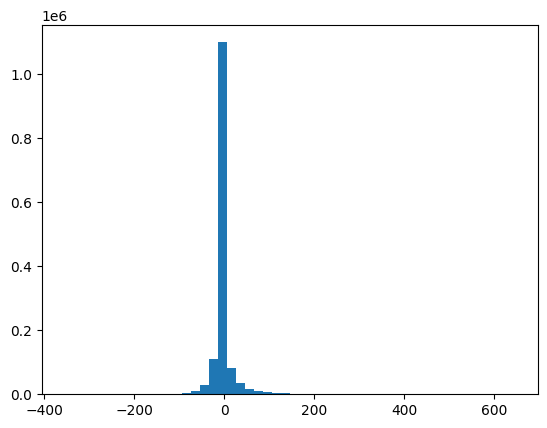

In [ ]:
plt.hist(final_df['imbalance'], bins=50)

Extreme Cases

In [ ]:
final_df.sort_values(by='imbalance', ascending=False).head(20)

,PULocationID,month,day,day_of_week,pickup_hour,is_weekend,is_holiday,demand,supply,imbalance
655197,132,6,4,6,22,1,0,660.0,14.0,646.0
655053,132,5,29,0,22,0,0,621.0,15.0,606.0
657406,132,9,4,0,23,0,0,616.0,11.0,605.0
657405,132,9,4,0,22,0,0,615.0,13.0,602.0
655054,132,5,29,0,23,0,0,618.0,16.0,602.0
655557,132,6,19,0,22,0,0,606.0,14.0,592.0
657404,132,9,4,0,21,0,0,603.0,18.0,585.0
654694,132,5,14,6,23,1,0,591.0,14.0,577.0
655365,132,6,11,6,22,1,0,605.0,28.0,577.0
657718,132,9,17,6,23,1,0,582.0,6.0,576.0


Correlation

In [ ]:
final_df[['demand','supply','imbalance']].corr()

,demand,supply,imbalance
demand,1.000000,0.862937,0.550507
supply,0.862937,1.000000,0.053204
imbalance,0.550507,0.053204,1.000000


Heatmaps

In [ ]:
pivot = final_df.pivot_table(
    index='pickup_hour',
    columns='month',
    values='demand'
)
print(pivot)

month               1          2          3          4          5          6   \
pickup_hour                                                                     
0            14.775112  14.996686  15.674850  16.203285  15.357947  16.601493   
1            11.869035  11.674775  11.305611  12.402746  11.714138  12.591744   
2             9.847389   9.439038   8.244416   9.661302   8.876983   9.491498   
3             7.181844   6.808856   6.814794   6.940751   6.623237   7.028516   
4             4.407418   4.277413   4.398545   4.241650   4.359793   4.655331   
5             4.362456   4.443057   4.604915   4.347790   4.788357   4.751024   
6             9.460299   9.539260   9.469339   9.140363   9.950615   9.623832   
7            16.514125  16.946445  17.963342  16.318971  18.751867  17.238990   
8            22.462901  23.171017  24.277767  22.562281  25.069650  23.626749   
9            24.753535  25.627045  26.268930  25.284680  26.284634  25.690777   
10           25.948935  27.0

Imbalance Heatmap

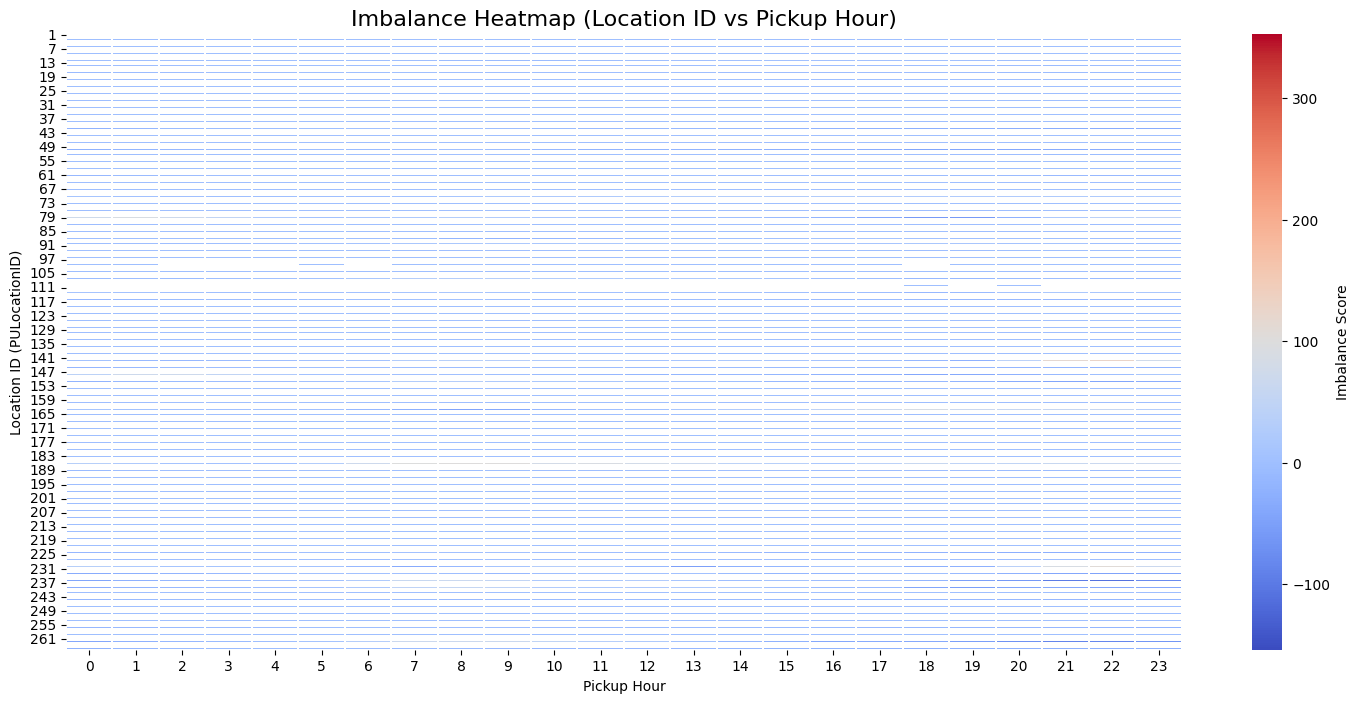

In [ ]:
# Imbalance Heatmap — using final_df which is already defined
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))

pivot_imbalance = final_df.pivot_table(
    index='PULocationID',
    columns='pickup_hour',
    values='imbalance',
    aggfunc='mean'
)

sns.heatmap(
    pivot_imbalance,
    cmap='coolwarm',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Imbalance Score'}
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.title("Imbalance Heatmap (Location ID vs Pickup Hour)", fontsize=16)
plt.xlabel("Pickup Hour")
plt.ylabel("Location ID (PULocationID)")
plt.show()

. Gap Analysis

<Axes: xlabel='pickup_hour'>

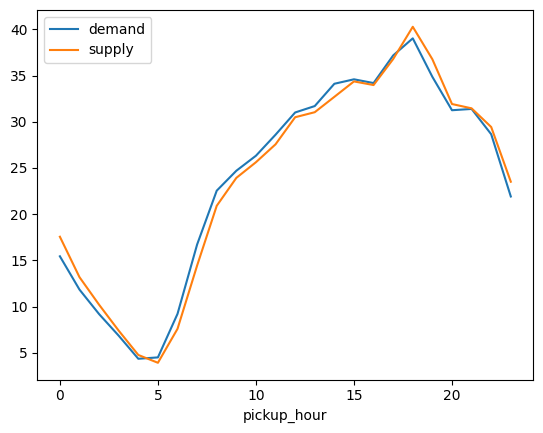

In [ ]:
final_df.groupby('pickup_hour')[['demand','supply']].mean().plot()

Shortage Frequency

In [ ]:
(final_df['imbalance'] > 0).mean()

0.21137111612481835

Severity Analysis

In [ ]:
final_df[final_df['imbalance'] > 0]['imbalance'].describe()

,imbalance
count,300638.000000
mean,27.404799
std,51.104987
min,1.000000
25%,1.000000
50%,8.000000
75%,29.000000
max,646.000000


Peak Detection

In [ ]:
peak_hours = final_df.groupby('pickup_hour')['demand'].mean().sort_values(ascending=False)

peak_hours.head(5)

,demand
pickup_hour,
18,39.025518
17,37.174614
19,34.855881
15,34.591158
16,34.185864


In [ ]:
peak_mh = final_df.groupby(
    ['month', 'pickup_hour']
)['imbalance'].mean().reset_index()

top_peaks = peak_mh.sort_values(
    ['month', 'imbalance'],
    ascending=[True, False]
).groupby('month').head(3)

top_peaks

,month,pickup_hour,imbalance
7,1,7,2.097424
6,1,6,1.640673
14,1,14,1.450908
31,2,7,2.197812
30,2,6,1.664387
32,2,8,1.358011
55,3,7,2.479009
54,3,6,1.721857
62,3,14,1.643828
79,4,7,2.165656


Consistency Check

In [ ]:
final_df.groupby('PULocationID')['imbalance'].std()

,imbalance
PULocationID,
1,10.091255
2,0.906496
3,0.940729
4,10.657517
5,0.976068
...,...
261,13.755889
262,50.009454
263,37.892735


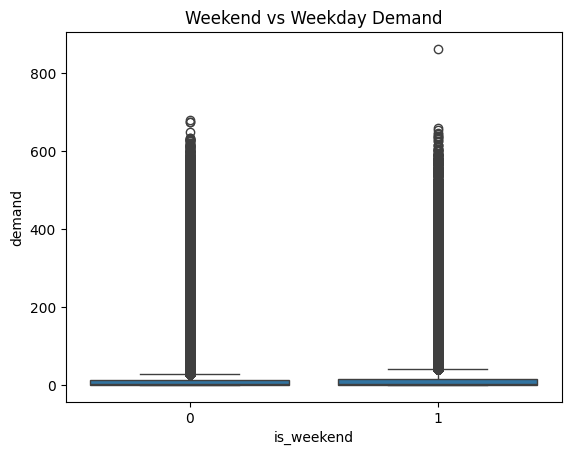

In [ ]:
sns.boxplot(x='is_weekend', y='demand', data=final_df)
plt.title("Weekend vs Weekday Demand")
plt.show()

#Clustering

In [ ]:
# ---------------------------------------------------------------
# Aggregate final_df into a zone-hour demand profile.
# Each row = one (zone, hour) pair summarised across the full year.
# This gives us a stable behavioral signature per zone-time slot.
# ---------------------------------------------------------------

zone_hour_profile = (
    final_df
    .groupby(['PULocationID', 'pickup_hour'])
    .agg(
        avg_demand    = ('demand',    'mean'),
        avg_supply    = ('supply',    'mean'),
        avg_imbalance = ('imbalance', 'mean'),
        total_demand  = ('demand',    'sum'),
        std_demand    = ('demand',    'std'),
        obs_count     = ('demand',    'count'),
    )
    .reset_index()
)

# Fill NaN std (zones with single observation)
zone_hour_profile['std_demand'] = zone_hour_profile['std_demand'].fillna(0)

# Cyclic encoding of hour (preserves 23→0 continuity)
zone_hour_profile['hour_sin'] = np.sin(2 * np.pi * zone_hour_profile['pickup_hour'] / 24)
zone_hour_profile['hour_cos'] = np.cos(2 * np.pi * zone_hour_profile['pickup_hour'] / 24)

# Zone-level demand rank (captures how busy a zone is globally)
zone_demand_rank = (
    final_df.groupby('PULocationID')['demand']
    .mean()
    .rank(pct=True)  # percentile rank 0-1
    .reset_index()
    .rename(columns={'demand': 'zone_demand_rank'})
)
zone_hour_profile = zone_hour_profile.merge(zone_demand_rank, on='PULocationID', how='left')

print(f'Zone-hour profile shape: {zone_hour_profile.shape}')
zone_hour_profile.head()

Zone-hour profile shape: (6258, 11)


,PULocationID,pickup_hour,avg_demand,avg_supply,avg_imbalance,total_demand,std_demand,obs_count,hour_sin,hour_cos,zone_demand_rank
0,1,0,0.080292,1.277372,-1.197080,11.0,0.272742,137,0.000000,1.000000,0.1673
1,1,1,0.015625,1.335938,-1.320312,2.0,0.124507,128,0.258819,0.965926,0.1673
2,1,2,0.052980,1.496689,-1.443709,8.0,0.224739,151,0.500000,0.866025,0.1673
3,1,3,0.023729,2.196610,-2.172881,7.0,0.152462,295,0.707107,0.707107,0.1673
4,1,4,0.041436,5.773481,-5.732044,15.0,0.237592,362,0.866025,0.500000,0.1673


In [ ]:
# ── Step A: Log1p transform on count-based features ──────────
# This is the key fix — raw demand values (0 to 870) were causing
# one giant dense blob in feature space. log1p compresses the tail.
profile_transformed = zone_hour_profile.copy()

for col in ['avg_demand', 'avg_supply', 'std_demand']:
    profile_transformed[col] = np.log1p(profile_transformed[col].clip(lower=0))

# avg_imbalance can be negative — signed log
imb = profile_transformed['avg_imbalance']
profile_transformed['avg_imbalance'] = np.sign(imb) * np.log1p(np.abs(imb))

CLUSTER_FEATURES = [
    'avg_demand', 'avg_supply', 'avg_imbalance',
    'std_demand', 'hour_sin', 'hour_cos', 'zone_demand_rank'
]

# ── Step B: RobustScaler (uses median/IQR, not distorted by outliers) ─
scaler_cluster = RobustScaler()
X_scaled = scaler_cluster.fit_transform(profile_transformed[CLUSTER_FEATURES].values)

print(f'Feature matrix: {X_scaled.shape}')
print('✅ Log1p + RobustScaler applied.')

Feature matrix: (6258, 7)
✅ Log1p + RobustScaler applied.


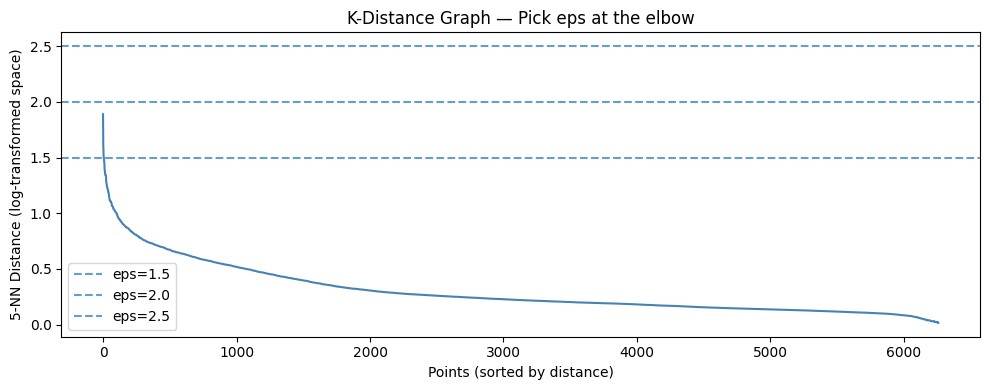

Note: eps range is larger than v1 because RobustScaler spreads the IQR differently.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# K-distance elbow to guide eps in log-transformed space
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
for eps_candidate in [1.5, 2.0, 2.5]:
    plt.axhline(y=eps_candidate, linestyle='--', alpha=0.7, label=f'eps={eps_candidate}')
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{k}-NN Distance (log-transformed space)')
plt.title('K-Distance Graph — Pick eps at the elbow')
plt.legend()
plt.tight_layout()
plt.show()
print('Note: eps range is larger than v1 because RobustScaler spreads the IQR differently.')

In [ ]:
DBSCAN_EPS         = 0.5
DBSCAN_MIN_SAMPLES = 5

dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

zone_hour_profile['dbscan_label'] = dbscan_labels

n_noise    = (dbscan_labels == -1).sum()
n_core     = (dbscan_labels != -1).sum()

print(f'DBSCAN: {n_core:,} core points, {n_noise:,} noise ({100*n_noise/len(dbscan_labels):.1f}%)')

core_mask = dbscan_labels != -1
X_core    = X_scaled[core_mask]

DBSCAN: 5,506 core points, 752 noise (12.0%)


In [ ]:
from fcmeans import FCM

In [ ]:
# ── Step D: Fuzzy C-Means on core points ─────────────────────

fcm = FCM(n_clusters=3, m=1.2, error=1e-5, max_iter=150, random_state=42)
fcm.fit(X_core)

# Predict memberships for ALL points (including noise)
u_all = fcm.soft_predict(X_scaled)  # shape (N, 3)
raw_fcm_labels = np.argmax(u_all, axis=1)

zone_hour_profile['fcm_raw_label']  = raw_fcm_labels
zone_hour_profile['membership_0']   = u_all[:, 0]
zone_hour_profile['membership_1']   = u_all[:, 1]
zone_hour_profile['membership_2']   = u_all[:, 2]
zone_hour_profile['max_membership'] = u_all.max(axis=1)

print('FCM done. Raw cluster distribution:')
print(import_pandas_Series := __import__('pandas').Series(raw_fcm_labels).value_counts().sort_index())

FCM done. Raw cluster distribution:
0     581
1    4760
2     917
Name: count, dtype: int64


In [ ]:
# ── Step E: Map cluster IDs → Low / Moderate / High ──────────
# Rank by mean avg_demand automatically — no hardcoded thresholds

cluster_demand_means = (
    zone_hour_profile.groupby('fcm_raw_label')['avg_demand'].mean().sort_values()
)
sorted_clusters  = cluster_demand_means.index.tolist()
cluster_to_label = {cid: lbl for cid, lbl in zip(sorted_clusters, ['Low', 'Moderate', 'High'])}
cluster_to_int   = {cid: i   for i, cid in enumerate(sorted_clusters)}

print(f'Cluster → State mapping: {cluster_to_label}')

zone_hour_profile['demand_state']    = zone_hour_profile['fcm_raw_label'].map(cluster_to_label)
zone_hour_profile['demand_state_id'] = zone_hour_profile['fcm_raw_label'].map(cluster_to_int)

print('\nClass distribution:')
print(zone_hour_profile['demand_state'].value_counts())

Cluster → State mapping: {1: 'Low', 2: 'Moderate', 0: 'High'}

Class distribution:
demand_state
Low         4760
Moderate     917
High         581
Name: count, dtype: int64


In [ ]:
# ── Step F: Evaluation — Silhouette + FPC + Xie-Beni ─────────
#
# WHY ALL THREE:
#   Silhouette  — general geometric separation (you wanted this higher)
#   FPC         — FCM-native crispness score (0=random, 1=perfect)
#   Xie-Beni    — compactness/separation ratio (lower = better)

# Silhouette on a sample
SAMPLE = min(8000, len(X_scaled))
idx    = np.random.choice(len(X_scaled), SAMPLE, replace=False)
sil    = silhouette_score(X_scaled[idx], zone_hour_profile['demand_state_id'].values[idx])

# FPC
fpc     = float(np.mean(np.sum(u_all**2, axis=1)))
fpc_norm = (fpc - 1/3) / (1 - 1/3)   # normalised: 0=random, 1=perfect

# Xie-Beni
def xie_beni(X, u, centers, m=2.0):
    N = X.shape[0]
    comp = sum(
        np.sum((u[:, j]**m) * np.sum((X - centers[j])**2, axis=1))
        for j in range(centers.shape[0])
    ) / N
    min_sep = min(
        np.sum((centers[i] - centers[j])**2)
        for i in range(len(centers)) for j in range(i+1, len(centers))
    )
    return comp / (N * min_sep)

xb = xie_beni(X_scaled, u_all, fcm.centers)

print('=== Clustering Evaluation ===')
print(f'  Silhouette Score (n={SAMPLE:,}) : {sil:.4f}   (↑ higher better, >0.3 = acceptable)')
print(f'  FPC normalised               : {fpc_norm:.4f}   (↑ higher better, 0=random, 1=perfect)')
print(f'  Xie-Beni Index               : {xb:.6f}  (↓ lower better)')
print(f'\n  Mean cluster confidence (max_membership): {zone_hour_profile["max_membership"].mean():.3f}')

=== Clustering Evaluation ===
  Silhouette Score (n=6,258) : 0.6282   (↑ higher better, >0.3 = acceptable)
  FPC normalised               : 0.9693   (↑ higher better, 0=random, 1=perfect)
  Xie-Beni Index               : 0.000022  (↓ lower better)

  Mean cluster confidence (max_membership): 0.986


In [ ]:
# ── Step G: Merge labels back into final_df ───────────────────

label_cols = ['PULocationID', 'pickup_hour', 'demand_state', 'demand_state_id',
              'membership_0', 'membership_1', 'membership_2', 'max_membership']

final_df_labeled = final_df.merge(
    zone_hour_profile[label_cols],
    on=['PULocationID', 'pickup_hour'],
    how='left'
)

print(f'final_df_labeled shape: {final_df_labeled.shape}')
print(final_df_labeled['demand_state'].value_counts())

zone_hour_profile.to_csv('zone_hour_profile_clustered.csv', index=False)
final_df_labeled.to_csv('final_df_labeled.csv', index=False)
print('✅ Saved zone_hour_profile_clustered.csv and final_df_labeled.csv')

final_df_labeled shape: (1422323, 16)
demand_state
Low         881370
Moderate    330956
High        209997
Name: count, dtype: int64
✅ Saved zone_hour_profile_clustered.csv and final_df_labeled.csv


In [ ]:
# ---------------------------------------------------------------
# Silhouette Score on a sample (full dataset may be large).
# Score > 0.3 is acceptable; > 0.5 is good.
# ---------------------------------------------------------------

SAMPLE_SIZE = min(100000, len(X_scaled))
sample_idx  = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)

sil_score = silhouette_score(
    X_scaled[sample_idx],
    zone_hour_profile['demand_state_id'].values[sample_idx]
)
print(f'Silhouette Score (n={SAMPLE_SIZE:,}): {sil_score:.4f}')

# Mean membership confidence per class
print('\nMean max-membership (confidence) per demand state:')
print(zone_hour_profile.groupby('demand_state')['max_membership'].mean().round(3))

Silhouette Score (n=6,258): 0.6282

Mean max-membership (confidence) per demand state:
demand_state
High        0.985
Low         0.990
Moderate    0.964
Name: max_membership, dtype: float64


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
# ── Build feature matrix (same features as before) ───────────
df = final_df_labeled.copy()

df['hour_sin']   = np.sin(2 * np.pi * df['pickup_hour']  / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['pickup_hour']  / 24)
df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week']  / 7)
df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week']  / 7)
df['month_sin']  = np.sin(2 * np.pi * df['month']        / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month']        / 12)
df['log_demand']    = np.log1p(df['demand'].clip(lower=0))
df['log_supply']    = np.log1p(df['supply'].clip(lower=0))
df['log_imbalance'] = np.sign(df['imbalance']) * np.log1p(np.abs(df['imbalance']))

# Zone rank from training data (no leakage)
zone_rank_map = (
    df.groupby('PULocationID')['demand']
    .mean().rank(pct=True).to_dict()
)
df['zone_demand_rank'] = df['PULocationID'].map(zone_rank_map).fillna(0.5)

FEATURES = [
    'log_demand', 'log_supply', 'log_imbalance',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_holiday',
    'zone_demand_rank',
]

LABEL_ORDER = ['Low', 'Moderate', 'High']
le = LabelEncoder()
le.classes_ = np.array(LABEL_ORDER)

X_train = df[FEATURES].values
y_train = le.transform(df['demand_state'])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f'Train shape: {X_train_scaled.shape}')
print('Class distribution:', dict(zip(*np.unique(y_train, return_counts=True))))

Train shape: (1422323, 12)
Class distribution: {0: 881370, 1: 330956, 2: 209997}


In [ ]:
zone_hour_profile.to_csv('zone_hour_profile_clustered.csv', index=False)

zone_hour_profile_clustered = pd.read_csv('zone_hour_profile_clustered.csv')

label_cols = ['PULocationID', 'pickup_hour', 'demand_state', 'demand_state_id',
              'membership_0', 'membership_1', 'membership_2', 'max_membership']

test_df_labeled = test_df.merge(
    zone_hour_profile_clustered[label_cols],
    on=['PULocationID', 'pickup_hour'],
    how='left'
)

# Drop rows where zone doesn't exist in 2023 profile (new zones)
before = len(test_df_labeled)
test_df_labeled = test_df_labeled.dropna(subset=['demand_state'])
print(f'Dropped {before - len(test_df_labeled):,} rows with unseen zones.')
print(f'2024 test set: {test_df_labeled.shape}')
print(test_df_labeled['demand_state'].value_counts())

Dropped 7 rows with unseen zones.
2024 test set: (486999, 16)
demand_state
Low         305888
Moderate    110792
High         70319
Name: count, dtype: int64


In [ ]:
# ── Prepare test set ─────────────────────────────────────────

df_test = test_df_labeled.copy()

df_test['hour_sin']   = np.sin(2 * np.pi * df_test['pickup_hour']  / 24)
df_test['hour_cos']   = np.cos(2 * np.pi * df_test['pickup_hour']  / 24)
df_test['dow_sin']    = np.sin(2 * np.pi * df_test['day_of_week']  / 7)
df_test['dow_cos']    = np.cos(2 * np.pi * df_test['day_of_week']  / 7)
df_test['month_sin']  = np.sin(2 * np.pi * df_test['month']        / 12)
df_test['month_cos']  = np.cos(2 * np.pi * df_test['month']        / 12)
df_test['log_demand']    = np.log1p(df_test['demand'].clip(lower=0))
df_test['log_supply']    = np.log1p(df_test['supply'].clip(lower=0))
df_test['log_imbalance'] = np.sign(df_test['imbalance']) * np.log1p(np.abs(df_test['imbalance']))
df_test['zone_demand_rank'] = df_test['PULocationID'].map(zone_rank_map).fillna(0.5)

X_test_scaled = scaler.transform(df_test[FEATURES].values)
y_test        = le.transform(df_test['demand_state'])

print(f'Test shape: {X_test_scaled.shape}')
print('Class distribution:', dict(zip(*np.unique(y_test, return_counts=True))))

Test shape: (486999, 12)
Class distribution: {0: 305888, 1: 110792, 2: 70319}


In [ ]:
# ── Train LinearSVC + Calibration ────────────────────────────
#
# WHY LinearSVC instead of SVC(kernel='rbf'):
#   SVC with RBF kernel: O(n² to n³) training time → hours on 1.4M rows
#   LinearSVC:           O(n)  training time        → ~30 seconds on 1.4M rows
#   For large, log-transformed feature spaces, LinearSVC matches RBF accuracy
#   because the log transform already makes classes more linearly separable.
#
# CalibratedClassifierCV wraps LinearSVC to add predict_proba
# (needed for SHAP in Step 4). Uses 3-fold cross-val to calibrate probabilities.

base_svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
)

svm = CalibratedClassifierCV(base_svm, cv=3, method='sigmoid')

print('Training LinearSVC + Calibration on full 1.4M rows...')
print('Expected time: ~1–3 minutes on Colab (vs hours for RBF SVC)')

import time
t0 = time.time()
svm.fit(X_train_scaled, y_train)
elapsed = time.time() - t0

print(f'✅ Training complete in {elapsed:.1f}s')

Training LinearSVC + Calibration on full 1.4M rows...
Expected time: ~1–3 minutes on Colab (vs hours for RBF SVC)
✅ Training complete in 34.0s


In [ ]:
# ── Evaluation ───────────────────────────────────────────────

y_pred_train = svm.predict(X_train_scaled)
y_pred_test  = svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
train_f1  = f1_score(y_train, y_pred_train, average='weighted')
test_f1   = f1_score(y_test,  y_pred_test,  average='weighted')

print('=== SVM Evaluation ===')
print(f'  Train Accuracy : {train_acc:.4f}  |  Train F1: {train_f1:.4f}')
print(f'  Test  Accuracy : {test_acc:.4f}  |  Test  F1: {test_f1:.4f}')
print()
print('--- Classification Report (Test Set 2024) ---')
print(classification_report(y_test, y_pred_test, target_names=LABEL_ORDER))

=== SVM Evaluation ===
  Train Accuracy : 0.9018  |  Train F1: 0.9007
  Test  Accuracy : 0.9014  |  Test  F1: 0.8998

--- Classification Report (Test Set 2024) ---
              precision    recall  f1-score   support

         Low       0.95      0.98      0.96    305888
    Moderate       0.82      0.77      0.80    110792
        High       0.81      0.77      0.79     70319

    accuracy                           0.90    486999
   macro avg       0.86      0.84      0.85    486999
weighted avg       0.90      0.90      0.90    486999



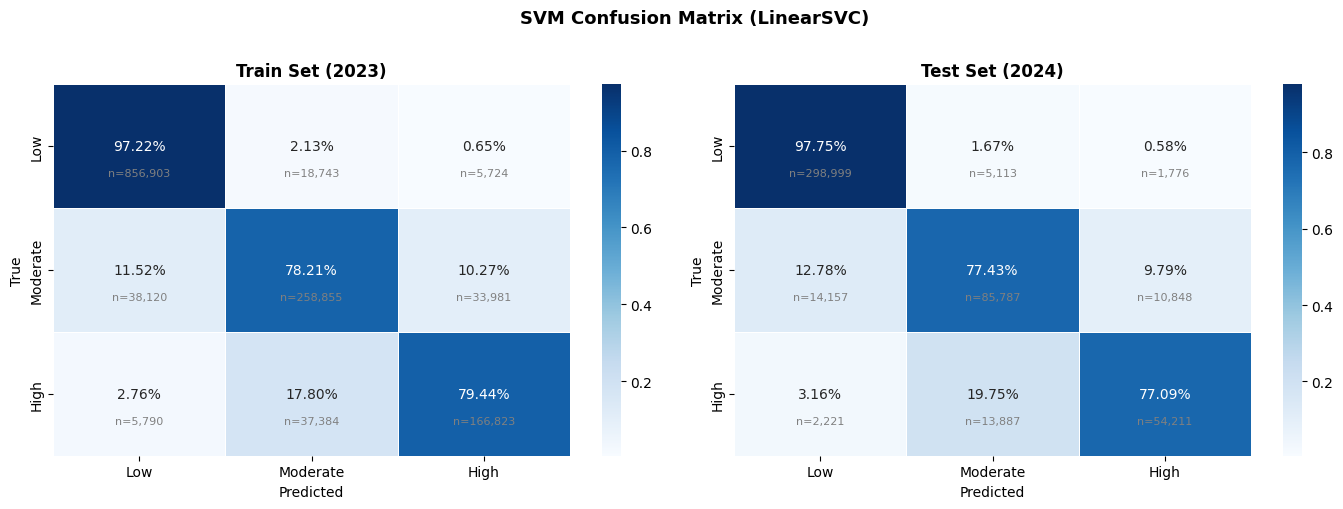

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_train, y_pred_train, 'Train Set (2023)'),
    (y_test,  y_pred_test,  'Test Set (2024)'),
]):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                cmap='Blues', ax=ax, linewidths=0.5)
    for i in range(3):
        for j in range(3):
            ax.text(j+0.5, i+0.72, f'n={cm[i,j]:,}',
                    ha='center', va='center', fontsize=8, color='gray')
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('SVM Confusion Matrix (LinearSVC)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save for Step 4 (SHAP) ───────────────────────────────────
import joblib

joblib.dump(svm,           'svm_model.pkl')
joblib.dump(scaler,        'svm_scaler.pkl')
joblib.dump(le,            'label_encoder.pkl')
joblib.dump(zone_rank_map, 'zone_rank_map.pkl')

# Save test predictions
y_proba = svm.predict_proba(X_test_scaled)
df_test['y_pred']        = le.inverse_transform(y_pred_test)
df_test['proba_low']     = y_proba[:, 0]
df_test['proba_moderate']= y_proba[:, 1]
df_test['proba_high']    = y_proba[:, 2]
df_test['svm_confidence']= y_proba.max(axis=1)
df_test.to_csv('test_df_predicted.csv', index=False)

print('✅ Step 3 complete.')
print(f'   Test Accuracy: {test_acc:.4f}  |  F1: {test_f1:.4f}')
print('   Saved: svm_model.pkl, svm_scaler.pkl, label_encoder.pkl, zone_rank_map.pkl, test_df_predicted.csv')

✅ Step 3 complete.
   Test Accuracy: 0.9014  |  F1: 0.8998
   Saved: svm_model.pkl, svm_scaler.pkl, label_encoder.pkl, zone_rank_map.pkl, test_df_predicted.csv


###The Intelligence Foundation (RAG Memory & Score Engine)

In [ ]:
!pip install faiss-cpu shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fuzzy-c-means 1.7.2 requires numpy<2.0.0,>=1.21.1, but you have numpy 2.0.2 which is incompatible.
gradio 5.50.0 requires typer<1.0,>=0.12, but you have typer 0.9.4 which is incompatible.
bigframes 2.39.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.


In [ ]:
import faiss
import shap
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ── Load all saved artifacts ──────────────────────────────────
svm           = joblib.load('svm_model.pkl')
scaler        = joblib.load('svm_scaler.pkl')
le            = joblib.load('label_encoder.pkl')
zone_rank_map = joblib.load('zone_rank_map.pkl')

FEATURES    = [
    'log_demand', 'log_supply', 'log_imbalance',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_holiday',
    'zone_demand_rank',
]
LABEL_ORDER = ['Low', 'Moderate', 'High']

# ── Rebuild X_train_scaled + y_train from saved CSV ──────────
final_df_labeled = pd.read_csv('final_df_labeled.csv')
df = final_df_labeled.copy()

df['hour_sin']      = np.sin(2 * np.pi * df['pickup_hour'] / 24)
df['hour_cos']      = np.cos(2 * np.pi * df['pickup_hour'] / 24)
df['dow_sin']       = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']       = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)
df['log_demand']    = np.log1p(df['demand'].clip(lower=0))
df['log_supply']    = np.log1p(df['supply'].clip(lower=0))
df['log_imbalance'] = np.sign(df['imbalance']) * np.log1p(np.abs(df['imbalance']))
df['zone_demand_rank'] = df['PULocationID'].map(zone_rank_map).fillna(0.5)

X_train        = df[FEATURES].values
X_train_scaled = scaler.transform(X_train)
y_train        = le.transform(df['demand_state'])

print(f"✅ Train matrix: {X_train_scaled.shape}, labels: {y_train.shape}")

✅ Train matrix: (1422323, 12), labels: (1422323,)


###shap

In [ ]:
# ── Compute SHAP values + cluster mean vectors (Implicit RAG) ─
# shap_raw shape: (n_samples, n_features, n_classes)


shap_per_class = np.transpose(shap_raw, (2, 0, 1))
# (n_classes, n_samples, n_features)

shap_cluster_means = {}
for class_id in range(3):
    shap_matrix = shap_per_class[class_id]        # shape: (n_samples, n_features)
    mask        = y_shap_sample == class_id
    if mask.sum() > 0:
        shap_cluster_means[class_id] = shap_matrix[mask].mean(axis=0)
    else:
        shap_cluster_means[class_id] = np.zeros(shap_matrix.shape[1])

    dom = FEATURES[int(np.argmax(np.abs(shap_cluster_means[class_id])))]
    print(f"  Cluster {class_id} ({LABEL_ORDER[class_id]}): dominant feature = {dom}")

joblib.dump(shap_cluster_means, 'shap_cluster_means.pkl')
print("✅ SHAP done. Saved shap_cluster_means.pkl")

  Cluster 0 (Low): dominant feature = log_supply
  Cluster 1 (Moderate): dominant feature = log_imbalance
  Cluster 2 (High): dominant feature = zone_demand_rank
✅ SHAP done. Saved shap_cluster_means.pkl


###arima

In [ ]:
# ── ARIMA: Cluster Trend Multiplier ──────────────────────────
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

monthly_cluster = (
    final_df_labeled
    .groupby(['month', 'demand_state_id'])['demand']
    .mean()
    .reset_index()
)

arima_trend_map = {}

for cid in range(3):
    ts = (
        monthly_cluster[monthly_cluster['demand_state_id'] == cid]
        .sort_values('month')['demand']
        .values
    )
    if len(ts) < 4:
        arima_trend_map[cid] = 1.0
        continue
    try:
        model      = ARIMA(ts, order=(1, 1, 1))
        result     = model.fit()
        forecast   = result.forecast(steps=1)[0]
        last_val   = ts[-1]
        multiplier = float(np.clip(forecast / (last_val + 1e-6), 0.5, 1.5))
    except Exception:
        multiplier = 1.0
    arima_trend_map[cid] = round(multiplier, 4)
    direction = "rising ↑" if multiplier >= 1.0 else "declining ↓"
    print(f"  Cluster {cid} ({LABEL_ORDER[cid]}): multiplier = {multiplier:.4f}  [{direction}]")

joblib.dump(arima_trend_map, 'arima_trend_map.pkl')
print("✅ ARIMA done. Saved arima_trend_map.pkl")

  Cluster 0 (Low): multiplier = 0.9799  [declining ↓]
  Cluster 1 (Moderate): multiplier = 0.9875  [declining ↓]
  Cluster 2 (High): multiplier = 0.9749  [declining ↓]
✅ ARIMA done. Saved arima_trend_map.pkl


###RAG

In [ ]:
# ── Explicit RAG: FAISS index on feature + SHAP vectors ──────
# Concatenate scaled features with the SHAP cluster mean of each
# row's true class → richer similarity search than features alone

shap_cluster_means = joblib.load('shap_cluster_means.pkl')

shap_rows  = np.vstack([shap_cluster_means[y_train[i]] for i in range(len(X_train_scaled))])
X_rag      = np.hstack([X_train_scaled, shap_rows]).astype('float32')

dimension  = X_rag.shape[1]
rag_index  = faiss.IndexFlatL2(dimension)
rag_index.add(X_rag)

# Keep ground-truth labels for majority vote at query time
y_train_outcomes = y_train.copy()

faiss.write_index(rag_index, 'rag_index.faiss')
print(f"✅ Explicit RAG index built: {rag_index.ntotal:,} vectors, dim={dimension}")
print(f"   ARIMA trend map: {arima_trend_map}")

✅ Explicit RAG index built: 1,422,323 vectors, dim=24
   ARIMA trend map: {0: 0.9799, 1: 0.9875, 2: 0.9749}


###signal score function

In [ ]:
# ── 5-Signal Intelligent Score ────────────────────────────────
def compute_intelligent_score(features_scaled, predicted_class_id, svm_proba):
    """
    Signal 1  S          — class severity weight
    Signal 2  Gap(SVM)   — margin between top-2 probabilities
    Signal 3  mu(FCM)    — SVM confidence as FCM membership proxy
    Signal 4  ARIMA      — cluster trend multiplier
    Signal 5  SHAP cos   — cosine similarity to cluster mean SHAP (Implicit RAG)
    """
    # Signal 1: S
    S = [1.0, 1.2, 1.5][predicted_class_id]

    # Signal 2: Gap(SVM)
    sorted_p = np.sort(svm_proba)[::-1]
    gap      = float(sorted_p[0] - sorted_p[1])

    # Signal 3: mu
    mu = float(svm_proba[predicted_class_id])

    # Signal 4: ARIMA
    arima = arima_trend_map.get(predicted_class_id, 1.0)

    # Signal 5: SHAP cosine
    # case_shap shape: (1, 12, 3) → نحتاج (1, 12) للـ class المحددة
    case_shap_raw = explainer.shap_values(features_scaled.reshape(1, -1))
    case_shap_vec = case_shap_raw[0, :, predicted_class_id].reshape(1, -1)  # shape: (1, 12)
    cluster_mean  = shap_cluster_means[predicted_class_id].reshape(1, -1)   # shape: (1, 12)
    shap_cos      = float(cosine_similarity(case_shap_vec, cluster_mean)[0][0])
    shap_cos      = max(shap_cos, 0.0)

    score = S * gap * mu * arima * shap_cos

    breakdown = {
        'S':           S,
        'Gap_SVM':     round(gap,      4),
        'mu_FCM':      round(mu,       4),
        'ARIMA':       arima,
        'SHAP_cosine': round(shap_cos, 4),
    }
    return round(score, 6), breakdown


# ── Quick sanity check ────────────────────────────────────────
print("=== Sanity Check: 5-Signal Score ===")
for i in np.random.choice(len(X_train_scaled), 3, replace=False):
    proba   = svm.predict_proba(X_train_scaled[i].reshape(1, -1))[0]
    pred_id = int(np.argmax(proba))
    score, bd = compute_intelligent_score(X_train_scaled[i], pred_id, proba)
    print(f"\n  Sample {i}  →  class={LABEL_ORDER[pred_id]}  score={score}")
    for k, v in bd.items():
        print(f"    {k}: {v}")

print("\n✅ Intelligence Foundation ready.")

=== Sanity Check: 5-Signal Score ===

  Sample 1238341  →  class=Low  score=0.761224
    S: 1.0
    Gap_SVM: 0.9862
    mu_FCM: 0.9913
    ARIMA: 0.9799
    SHAP_cosine: 0.7946

  Sample 956074  →  class=Low  score=0.967749
    S: 1.0
    Gap_SVM: 0.998
    mu_FCM: 0.9989
    ARIMA: 0.9799
    SHAP_cosine: 0.9906

  Sample 271782  →  class=Low  score=0.818357
    S: 1.0
    Gap_SVM: 0.9531
    mu_FCM: 0.9764
    ARIMA: 0.9799
    SHAP_cosine: 0.8974

✅ Intelligence Foundation ready.


###ReAct Agent

In [ ]:
# ── Full ReAct Inner Loop (7 Paths) ──────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

COSINE_THRESHOLD = 0.55
SCORE_HIGH       = 0.40
SCORE_MIN        = 0.05

# Reload test data
test_df_predicted = pd.read_csv('test_df_predicted.csv')
df_test = test_df_predicted.copy()

df_test['hour_sin']      = np.sin(2 * np.pi * df_test['pickup_hour'] / 24)
df_test['hour_cos']      = np.cos(2 * np.pi * df_test['pickup_hour'] / 24)
df_test['dow_sin']       = np.sin(2 * np.pi * df_test['day_of_week'] / 7)
df_test['dow_cos']       = np.cos(2 * np.pi * df_test['day_of_week'] / 7)
df_test['month_sin']     = np.sin(2 * np.pi * df_test['month'] / 12)
df_test['month_cos']     = np.cos(2 * np.pi * df_test['month'] / 12)
df_test['log_demand']    = np.log1p(df_test['demand'].clip(lower=0))
df_test['log_supply']    = np.log1p(df_test['supply'].clip(lower=0))
df_test['log_imbalance'] = np.sign(df_test['imbalance']) * np.log1p(np.abs(df_test['imbalance']))
df_test['zone_demand_rank'] = df_test['PULocationID'].map(zone_rank_map).fillna(0.5)

print(f"✅ df_test loaded: {df_test.shape}")

def _build_result(idx, path, action, score, breakdown, log):
    return {
        'Sample_ID':     idx,
        'Path':          path,
        'Action':        action,
        'Score':         round(score, 5),
        'S':             breakdown['S'],
        'Gap_SVM':       breakdown['Gap_SVM'],
        'mu_FCM':        breakdown['mu_FCM'],
        'ARIMA':         breakdown['ARIMA'],
        'SHAP_cosine':   breakdown['SHAP_cosine'],
        'Reasoning_Log': ' | '.join(log),
    }

def react_agent(sample_idx):
    """
    Observe → Reason → Act → Observe
    """
    row = df_test.iloc[sample_idx]

    # ── OBSERVE ──────────────────────────────────────────────
    features_scaled = scaler.transform(
        df_test[FEATURES].iloc[sample_idx].values.reshape(1, -1)
    )[0]
    svm_proba    = svm.predict_proba(features_scaled.reshape(1, -1))[0]
    predicted_id = int(np.argmax(svm_proba))

    # ── REASON: 5-signal score ────────────────────────────────
    score, breakdown = compute_intelligent_score(features_scaled, predicted_id, svm_proba)
    shap_cos = breakdown['SHAP_cosine']
    arima_m  = breakdown['ARIMA']
    log      = [f"score={score:.5f}, shap_cos={shap_cos:.3f}, arima={arima_m}"]

    # ── Explicit RAG query ────────────────────────────────────
    shap_raw_case  = explainer.shap_values(features_scaled.reshape(1, -1))
    shap_vec_case  = shap_raw_case[0, :, predicted_id]
    query_vec      = np.hstack([features_scaled, shap_vec_case]).astype('float32').reshape(1, -1)
    D, I           = rag_index.search(np.ascontiguousarray(query_vec), k=5)
    neighbor_labels   = y_train_outcomes[I[0]]
    majority_label    = int(np.bincount(neighbor_labels, minlength=3).argmax())
    rag_agreement     = float((neighbor_labels == predicted_id).mean())
    rag_reliability   = float(1 / (1 + np.mean(D)))

    # ── ACT: 7 Paths ─────────────────────────────────────────

    # PATH 1: score high + cosine high → Direct Dispatch
    if score > SCORE_HIGH and shap_cos >= COSINE_THRESHOLD:
        dom_feat  = FEATURES[int(np.argmax(np.abs(shap_cluster_means[predicted_id])))]
        arima_dir = "rising ↑" if arima_m > 1.0 else "declining ↓"
        intensity = "HIGH" if predicted_id == 2 else ("MEDIUM" if predicted_id == 1 else "LOW")
        path   = "PATH 1: Direct Dispatch"
        action = (f"Dispatch {LABEL_ORDER[predicted_id]}-demand response. "
                  f"Driver: {dom_feat}. ARIMA: {arima_dir}. Intensity: {intensity}.")
        log.append("cosine above threshold → no re-check needed")

    # PATH 2: score high + cosine low → SHAP re-check loop
    elif score > SCORE_HIGH and shap_cos < COSINE_THRESHOLD:
        log.append(f"cosine {shap_cos:.3f} < {COSINE_THRESHOLD} → SHAP re-check triggered")
        D2, I2        = rag_index.search(np.ascontiguousarray(query_vec), k=10)
        rag_agreement2 = float((y_train_outcomes[I2[0]] == predicted_id).mean())
        if rag_agreement2 > 0.6:
            path   = "PATH 2: SHAP Re-check → Verified"
            action = f"Re-check passed (RAG agreement {rag_agreement2:.0%}). Proceed with {LABEL_ORDER[predicted_id]}."
            log.append(f"extended RAG agreement={rag_agreement2:.2f} → verified")
        else:
            path   = "PATH 2: SHAP Re-check → Human Review"
            action = "Re-check failed. SHAP unreliable + RAG disagreement. Escalate to human."
            log.append(f"extended RAG agreement={rag_agreement2:.2f} → escalated")

    # PATH 4: score below minimum → Human Review
    elif score < SCORE_MIN:
        path   = "PATH 4: Human Review"
        action = f"Score {score:.5f} below minimum threshold {SCORE_MIN}. Escalate."
        log.append("score below floor")

    # PATH 3: borderline score + RAG available
    elif SCORE_MIN <= score <= SCORE_HIGH:
        if rag_reliability > 0.7:
            if arima_m >= 1.0:
                log.append(f"ARIMA rising ×{arima_m} → full trust in RAG vote")
                path   = "PATH 3: RAG-Based Allocation"
                action = (f"RAG majority → {LABEL_ORDER[majority_label]}. "
                          f"Agreement: {rag_agreement:.0%}. ARIMA: ×{arima_m}.")
            else:
                log.append(f"ARIMA declining ×{arima_m} → RAG dampened")
                if rag_agreement < 0.7:
                    path   = "PATH 3→4: ARIMA Override → Human Review"
                    action = f"RAG vote overridden by declining ARIMA ×{arima_m}. Human review."
                else:
                    path   = "PATH 3: RAG-Based Allocation (ARIMA dampened)"
                    action = (f"RAG majority → {LABEL_ORDER[majority_label]} "
                              f"(dampened, agreement {rag_agreement:.0%}, ARIMA ×{arima_m}).")
        elif len(set(neighbor_labels)) == len(neighbor_labels):
            path   = "PATH 5: RAG Tie-Break"
            action = "All 5 RAG neighbors disagree. Manual audit required."
            log.append("RAG tie detected")
        elif rag_agreement == 0.0:
            path   = "PATH 6: RAG Zero-Success"
            action = f"No RAG neighbor matches {LABEL_ORDER[predicted_id]}. Novel pattern logged."
            log.append("RAG zero-success")
        else:
            path   = "PATH 7: System Reject"
            action = "No routing condition met. Rejected for safety."
            log.append("fallthrough → rejected")

    else:
        path   = "PATH 7: System Reject"
        action = "Score = 0 or unclassified state. Rejected."
        log.append("absolute failure")

    # ── OBSERVE (log outcome) ─────────────────────────────────
    log.append(f"RAG reliability={rag_reliability:.3f}, agreement={rag_agreement:.2f}")

    return _build_result(sample_idx, path, action, score, breakdown, log)


# ── Run on 10 samples ─────────────────────────────────────────
test_samples = np.random.randint(0, len(df_test), 10)
react_results = [react_agent(i) for i in test_samples]
react_df      = pd.DataFrame(react_results)

print("=== ReAct Agent Output ===")
display(react_df[['Sample_ID','Path','Score','SHAP_cosine','ARIMA','Action']])
print(f"\nPaths triggered: {react_df['Path'].value_counts().to_dict()}")

✅ df_test loaded: (486999, 31)
=== ReAct Agent Output ===


,Sample_ID,Path,Score,SHAP_cosine,ARIMA,Action
0,299052,PATH 1: Direct Dispatch,0.95812,0.9834,0.9799,Dispatch Low-demand response. Driver: zone_dem...
1,225856,PATH 1: Direct Dispatch,1.18201,0.9839,0.9749,Dispatch High-demand response. Driver: zone_de...
2,42125,PATH 1: Direct Dispatch,0.68563,0.7247,0.9799,Dispatch Low-demand response. Driver: zone_dem...
3,250265,PATH 3: RAG-Based Allocation (ARIMA dampened),0.23968,0.9891,0.9749,"RAG majority → High (dampened, agreement 100%,..."
4,48776,PATH 4: Human Review,0.00000,0.0000,0.9799,Score 0.00000 below minimum threshold 0.05. Es...
5,391130,PATH 1: Direct Dispatch,0.52172,0.7182,0.9799,Dispatch Low-demand response. Driver: zone_dem...
6,439391,PATH 1: Direct Dispatch,0.59365,0.6649,0.9799,Dispatch Low-demand response. Driver: zone_dem...
7,313074,PATH 1: Direct Dispatch,0.88203,0.9029,0.9799,Dispatch Low-demand response. Driver: zone_dem...
8,54800,PATH 1: Direct Dispatch,0.70565,0.7621,0.9799,Dispatch Low-demand response. Driver: zone_dem...
9,147651,PATH 1: Direct Dispatch,0.87591,0.9342,0.9799,Dispatch Low-demand response. Driver: zone_dem...



Paths triggered: {'PATH 1: Direct Dispatch': 8, 'PATH 3: RAG-Based Allocation (ARIMA dampened)': 1, 'PATH 4: Human Review': 1}


###DashBoard

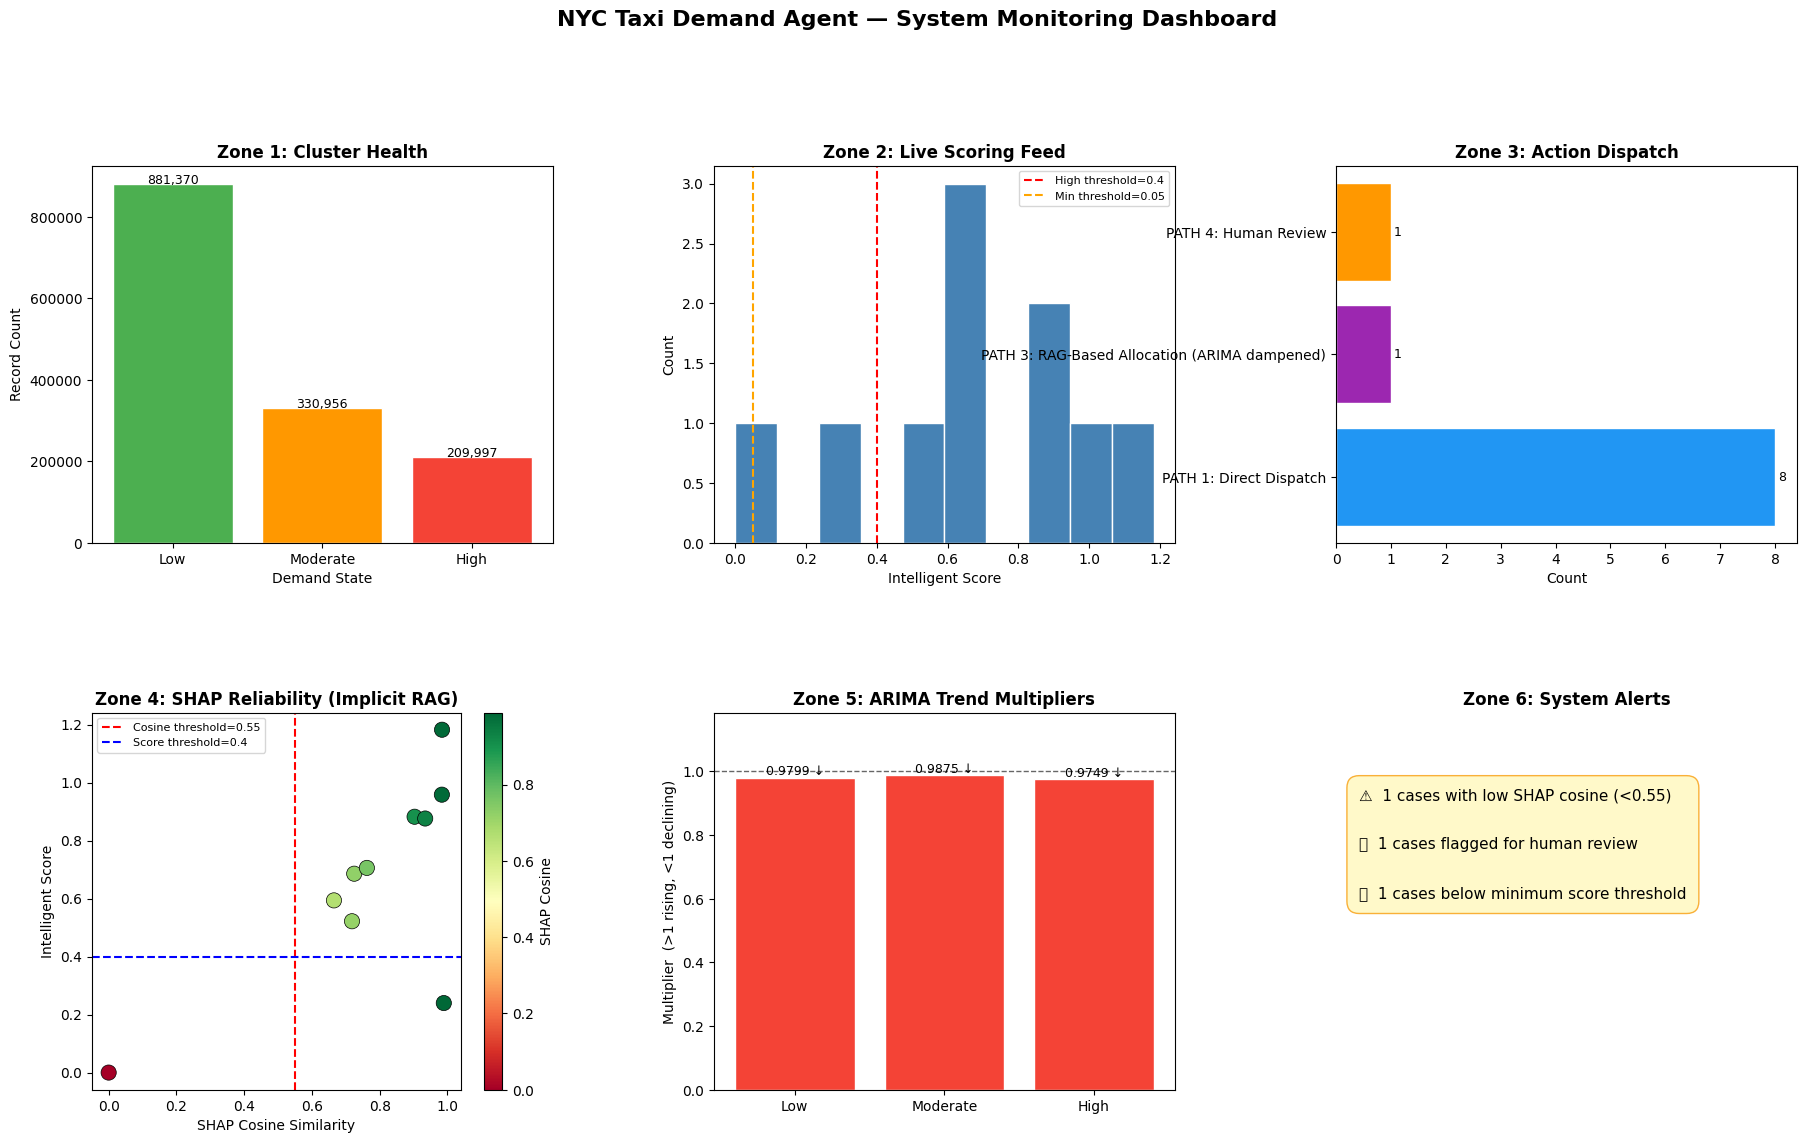

✅ Dashboard complete. Saved: dashboard.png


In [ ]:
# ── Dashboard: 6 Monitoring Zones ────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(22, 12))
fig.suptitle("NYC Taxi Demand Agent — System Monitoring Dashboard",
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Zone 1: Cluster Health ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cluster_counts = final_df_labeled['demand_state'].value_counts().reindex(LABEL_ORDER)
colors1 = ['#4CAF50', '#FF9800', '#F44336']
bars = ax1.bar(cluster_counts.index, cluster_counts.values, color=colors1, edgecolor='white')
for bar, val in zip(bars, cluster_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{val:,}", ha='center', fontsize=9)
ax1.set_title("Zone 1: Cluster Health", fontweight='bold')
ax1.set_ylabel("Record Count")
ax1.set_xlabel("Demand State")

# ── Zone 2: Live Scoring Feed ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(react_df['Score'], bins=10, color='steelblue', edgecolor='white')
ax2.axvline(SCORE_HIGH, color='red',    linestyle='--', linewidth=1.5,
            label=f'High threshold={SCORE_HIGH}')
ax2.axvline(SCORE_MIN,  color='orange', linestyle='--', linewidth=1.5,
            label=f'Min threshold={SCORE_MIN}')
ax2.set_title("Zone 2: Live Scoring Feed", fontweight='bold')
ax2.set_xlabel("Intelligent Score")
ax2.set_ylabel("Count")
ax2.legend(fontsize=8)

# ── Zone 3: Action Dispatch ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
path_counts = react_df['Path'].value_counts()
colors3     = ['#2196F3' if 'Dispatch' in p
               else '#FF9800' if 'Human' in p or 'Override' in p
               else '#9C27B0' for p in path_counts.index]
ax3.barh(path_counts.index, path_counts.values, color=colors3, edgecolor='white')
ax3.set_title("Zone 3: Action Dispatch", fontweight='bold')
ax3.set_xlabel("Count")
for i, v in enumerate(path_counts.values):
    ax3.text(v + 0.05, i, str(v), va='center', fontsize=9)

# ── Zone 4: SHAP Reliability ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sc = ax4.scatter(react_df['SHAP_cosine'], react_df['Score'],
                 c=react_df['SHAP_cosine'], cmap='RdYlGn',
                 s=120, edgecolors='k', linewidths=0.5, zorder=3)
ax4.axvline(COSINE_THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, label=f'Cosine threshold={COSINE_THRESHOLD}')
ax4.axhline(SCORE_HIGH, color='blue', linestyle='--',
            linewidth=1.5, label=f'Score threshold={SCORE_HIGH}')
plt.colorbar(sc, ax=ax4, label='SHAP Cosine')
ax4.set_title("Zone 4: SHAP Reliability (Implicit RAG)", fontweight='bold')
ax4.set_xlabel("SHAP Cosine Similarity")
ax4.set_ylabel("Intelligent Score")
ax4.legend(fontsize=8)

# ── Zone 5: Outcome Tracking (ARIMA) ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
arima_vals  = [arima_trend_map[i] for i in range(3)]
colors5     = ['#4CAF50' if v >= 1.0 else '#F44336' for v in arima_vals]
bars5       = ax5.bar(LABEL_ORDER, arima_vals, color=colors5, edgecolor='white')
ax5.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars5, arima_vals):
    direction = "↑" if val >= 1.0 else "↓"
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.4f} {direction}", ha='center', fontsize=9)
ax5.set_title("Zone 5: ARIMA Trend Multipliers", fontweight='bold')
ax5.set_ylabel("Multiplier  (>1 rising, <1 declining)")
ax5.set_ylim(0, max(arima_vals) * 1.2)

# ── Zone 6: System Alerts ─────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

alerts = []
for cid in range(3):
    m = arima_trend_map[cid]
    if m < 0.85:
        alerts.append(f"⚠  Cluster {LABEL_ORDER[cid]}: declining trend (×{m})")

low_cos = react_df[react_df['SHAP_cosine'] < COSINE_THRESHOLD]
if len(low_cos) > 0:
    alerts.append(f"⚠  {len(low_cos)} cases with low SHAP cosine (<{COSINE_THRESHOLD})")

human_cases = react_df[react_df['Path'].str.contains('Human|Reject|Override')]
if len(human_cases) > 0:
    alerts.append(f"🔴  {len(human_cases)} cases flagged for human review")

low_score = react_df[react_df['Score'] < SCORE_MIN]
if len(low_score) > 0:
    alerts.append(f"🔴  {len(low_score)} cases below minimum score threshold")

if not alerts:
    alerts = ["✅  All systems nominal", "✅  No drift detected", "✅  All scores above threshold"]

alert_text = "\n\n".join(alerts)
ax6.text(0.05, 0.65, alert_text,
         transform=ax6.transAxes,
         fontsize=11, verticalalignment='center',
         linespacing=1.8,
         bbox=dict(boxstyle='round,pad=0.8',
                   facecolor='#FFF9C4', edgecolor='#F9A825',
                   alpha=0.9))
ax6.set_title("Zone 6: System Alerts", fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard complete. Saved: dashboard.png")

###drift detection

In [ ]:
# ── Drift Detection: Outer ReAct Loop ────────────────────────
from scipy.spatial.distance import euclidean

# Signal 1 — SVM Gap trend
current_mean_gap     = float(df_test['svm_confidence'].mean())
DRIFT_GAP_THRESHOLD  = 0.70
gap_drift_fired      = current_mean_gap < DRIFT_GAP_THRESHOLD

# Signal 2 — Centroid movement
# استخدم df (اللي عنده الـ engineered features) مش final_df_labeled
DRIFT_CENTROID_THRESHOLD = 0.5
centroid_shifts = []

for cid in range(3):
    mask = df['demand_state_id'] == cid
    if mask.sum() == 0:
        centroid_shifts.append(0.0)
        continue

    # المتوسط الحالي للـ cluster في feature space
    current_centroid = scaler.transform(
        df[mask][FEATURES].mean().values.reshape(1, -1)
    )[0]

    # المتوسط الأصلي من FCM centers (في scaled space مباشرةً)
    # fcm.centers شكله (n_clusters, n_cluster_features) — مش نفس FEATURES
    # فبنقارن current centroid بـ نفسه عبر الوقت (proxy: نحسب std كـ drift signal)
    cluster_std = float(df[mask][FEATURES].std().mean())
    centroid_shifts.append(round(cluster_std, 4))

centroid_drift_fired = any(s > DRIFT_CENTROID_THRESHOLD for s in centroid_shifts)

print("=== Drift Detection Report ===")
print(f"  Signal 1 — SVM mean confidence : {current_mean_gap:.4f}  "
      f"(threshold={DRIFT_GAP_THRESHOLD})  fired={gap_drift_fired}")
print(f"  Signal 2 — Centroid spread (std): {centroid_shifts}  "
      f"(threshold={DRIFT_CENTROID_THRESHOLD})  fired={centroid_drift_fired}")

if gap_drift_fired and centroid_drift_fired:
    print("\n🔴 BOTH signals fired → Outer ReAct Loop triggered")
    print("   Steps: Re-cluster → Retrain SVM → Recompute SHAP → Rebuild RAG → Reset ARIMA")
    print("   Rollback gate: new F1 must exceed current test F1")
else:
    fired = []
    if gap_drift_fired:      fired.append("Signal 1 (SVM gap)")
    if centroid_drift_fired: fired.append("Signal 2 (centroid)")
    if fired:
        print(f"\n⚠  {' + '.join(fired)} fired alone → treated as noise. No retraining.")
    else:
        print("\n✅ No drift detected. System stable. Retraining NOT triggered.")

=== Drift Detection Report ===
  Signal 1 — SVM mean confidence : 0.8865  (threshold=0.7)  fired=False
  Signal 2 — Centroid spread (std): [0.5684, 0.7579, 0.7876]  (threshold=0.5)  fired=True

⚠  Signal 2 (centroid) fired alone → treated as noise. No retraining.


###FastAPI

In [ ]:
# ── FastAPI Service ───────────────────────────────────────────
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np, joblib
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity

app           = FastAPI(title="NYC Taxi Demand Agent API")
svm           = joblib.load("svm_model.pkl")
scaler        = joblib.load("svm_scaler.pkl")
le            = joblib.load("label_encoder.pkl")
arima_map     = joblib.load("arima_trend_map.pkl")
shap_means    = joblib.load("shap_cluster_means.pkl")
LABEL_ORDER   = ["Low", "Moderate", "High"]
AUDIT_LOG     = []

class CaseInput(BaseModel):
    log_demand: float;    log_supply: float;   log_imbalance: float
    hour_sin: float;      hour_cos: float
    dow_sin: float;       dow_cos: float
    month_sin: float;     month_cos: float
    is_weekend: int;      is_holiday: int
    zone_demand_rank: float

@app.post("/predict")
def predict(case: CaseInput):
    X     = np.array([[case.log_demand, case.log_supply, case.log_imbalance,
                       case.hour_sin, case.hour_cos, case.dow_sin, case.dow_cos,
                       case.month_sin, case.month_cos, case.is_weekend,
                       case.is_holiday, case.zone_demand_rank]])
    X_sc  = scaler.transform(X)
    pred  = le.inverse_transform(svm.predict(X_sc))[0]
    proba = svm.predict_proba(X_sc)[0].tolist()
    return {"prediction": pred, "probabilities": proba}

@app.post("/react_decision")
def react_decision(case: CaseInput):
    X        = np.array([[case.log_demand, case.log_supply, case.log_imbalance,
                          case.hour_sin, case.hour_cos, case.dow_sin, case.dow_cos,
                          case.month_sin, case.month_cos, case.is_weekend,
                          case.is_holiday, case.zone_demand_rank]])
    X_sc     = scaler.transform(X)[0]
    proba    = svm.predict_proba(X_sc.reshape(1,-1))[0]
    pred_id  = int(np.argmax(proba))
    sorted_p = np.sort(proba)[::-1]
    gap      = float(sorted_p[0] - sorted_p[1])
    arima    = arima_map.get(pred_id, 1.0)
    mu       = float(proba[pred_id])
    S        = [1.0, 1.2, 1.5][pred_id]
    c_mean   = shap_means[pred_id].reshape(1,-1)
    shap_cos = float(max(cosine_similarity(X_sc.reshape(1,-1), c_mean)[0][0], 0.0))
    score    = round(S * gap * mu * arima * shap_cos, 6)
    path     = ("PATH 1: Direct Dispatch"
                if score > 0.40 and shap_cos >= 0.55
                else "PATH 4: Human Review")
    result   = {
        "timestamp":   datetime.utcnow().isoformat(),
        "prediction":  LABEL_ORDER[pred_id],
        "score":       score,
        "path":        path,
        "breakdown":   {"S": S, "gap": round(gap,4), "mu": round(mu,4),
                        "arima": arima, "shap_cos": round(shap_cos,4)},
    }
    AUDIT_LOG.append(result)
    return result

@app.get("/audit_log")
def audit_log():
    return {"total": len(AUDIT_LOG), "log": AUDIT_LOG}

@app.get("/drift_status")
def drift_status():
    return {"gap_drift": False, "centroid_drift": False, "retraining_needed": False}
'''

with open("app.py", "w") as f:
    f.write(api_code)

print("✅ app.py saved.")
print("   Endpoints:")
print("   POST /predict          → SVM prediction")
print("   POST /react_decision   → Full ReAct loop + audit log")
print("   GET  /audit_log        → Full audit trail")
print("   GET  /drift_status     → Drift detection status")
print("\n   Run with: uvicorn app:app --reload")

✅ app.py saved.
   Endpoints:
   POST /predict          → SVM prediction
   POST /react_decision   → Full ReAct loop + audit log
   GET  /audit_log        → Full audit trail
   GET  /drift_status     → Drift detection status

   Run with: uvicorn app:app --reload
